In [1]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
base_dir = "/home/users/mendrika/NCAST/Output/Optimisation/Dakar"

csv_files = glob.glob(
    f"{base_dir}/**/*.csv",
    recursive=True
)

dfs = []

for file in csv_files:

    df = pd.read_csv(file)

    dfs.append(df)

results = pd.concat(
    dfs,
    ignore_index=True
)

In [10]:
results

,model,lead_time,C,class_weight,train_auc,val_auc,test_auc,train_brier,val_brier,test_brier,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,dropout,batch_size,architecture,min_samples_leaf
0,LR,3,0.01,balanced,0.879112,0.938514,0.857421,0.146580,0.140291,0.149531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LR,6,0.01,balanced,0.783413,0.861586,0.755624,0.198530,0.187305,0.196907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LR,1,0.01,NaN,0.960321,0.977939,0.955923,0.008527,0.012459,0.009039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SVM,1,100.00,balanced,0.964446,0.974408,0.957932,0.009229,0.013173,0.009888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SVM,6,0.10,NaN,0.782145,0.865068,0.745549,0.010133,0.014125,0.011449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,SVM,3,100.00,balanced,0.879550,0.937483,0.855442,0.010380,0.014658,0.011524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,XGB,3,NaN,NaN,0.969456,0.952591,0.891744,0.008333,0.014311,0.011101,100.0,5.0,0.0500,0.8,0.8,NaN,NaN,NaN,NaN
7,XGB,1,NaN,NaN,0.989902,0.985900,0.974685,0.005553,0.010663,0.007579,500.0,5.0,0.0100,1.0,1.0,NaN,NaN,NaN,NaN
8,XGB,6,NaN,NaN,0.965618,0.875765,0.786966,0.009321,0.013997,0.011399,100.0,7.0,0.0100,1.0,0.8,NaN,NaN,NaN,NaN
9,MLP,1,NaN,NaN,0.964723,0.981847,0.960046,0.009195,0.011173,0.009725,NaN,NaN,0.0010,NaN,NaN,0.2,128.0,"[128, 64, 32, 16]",NaN


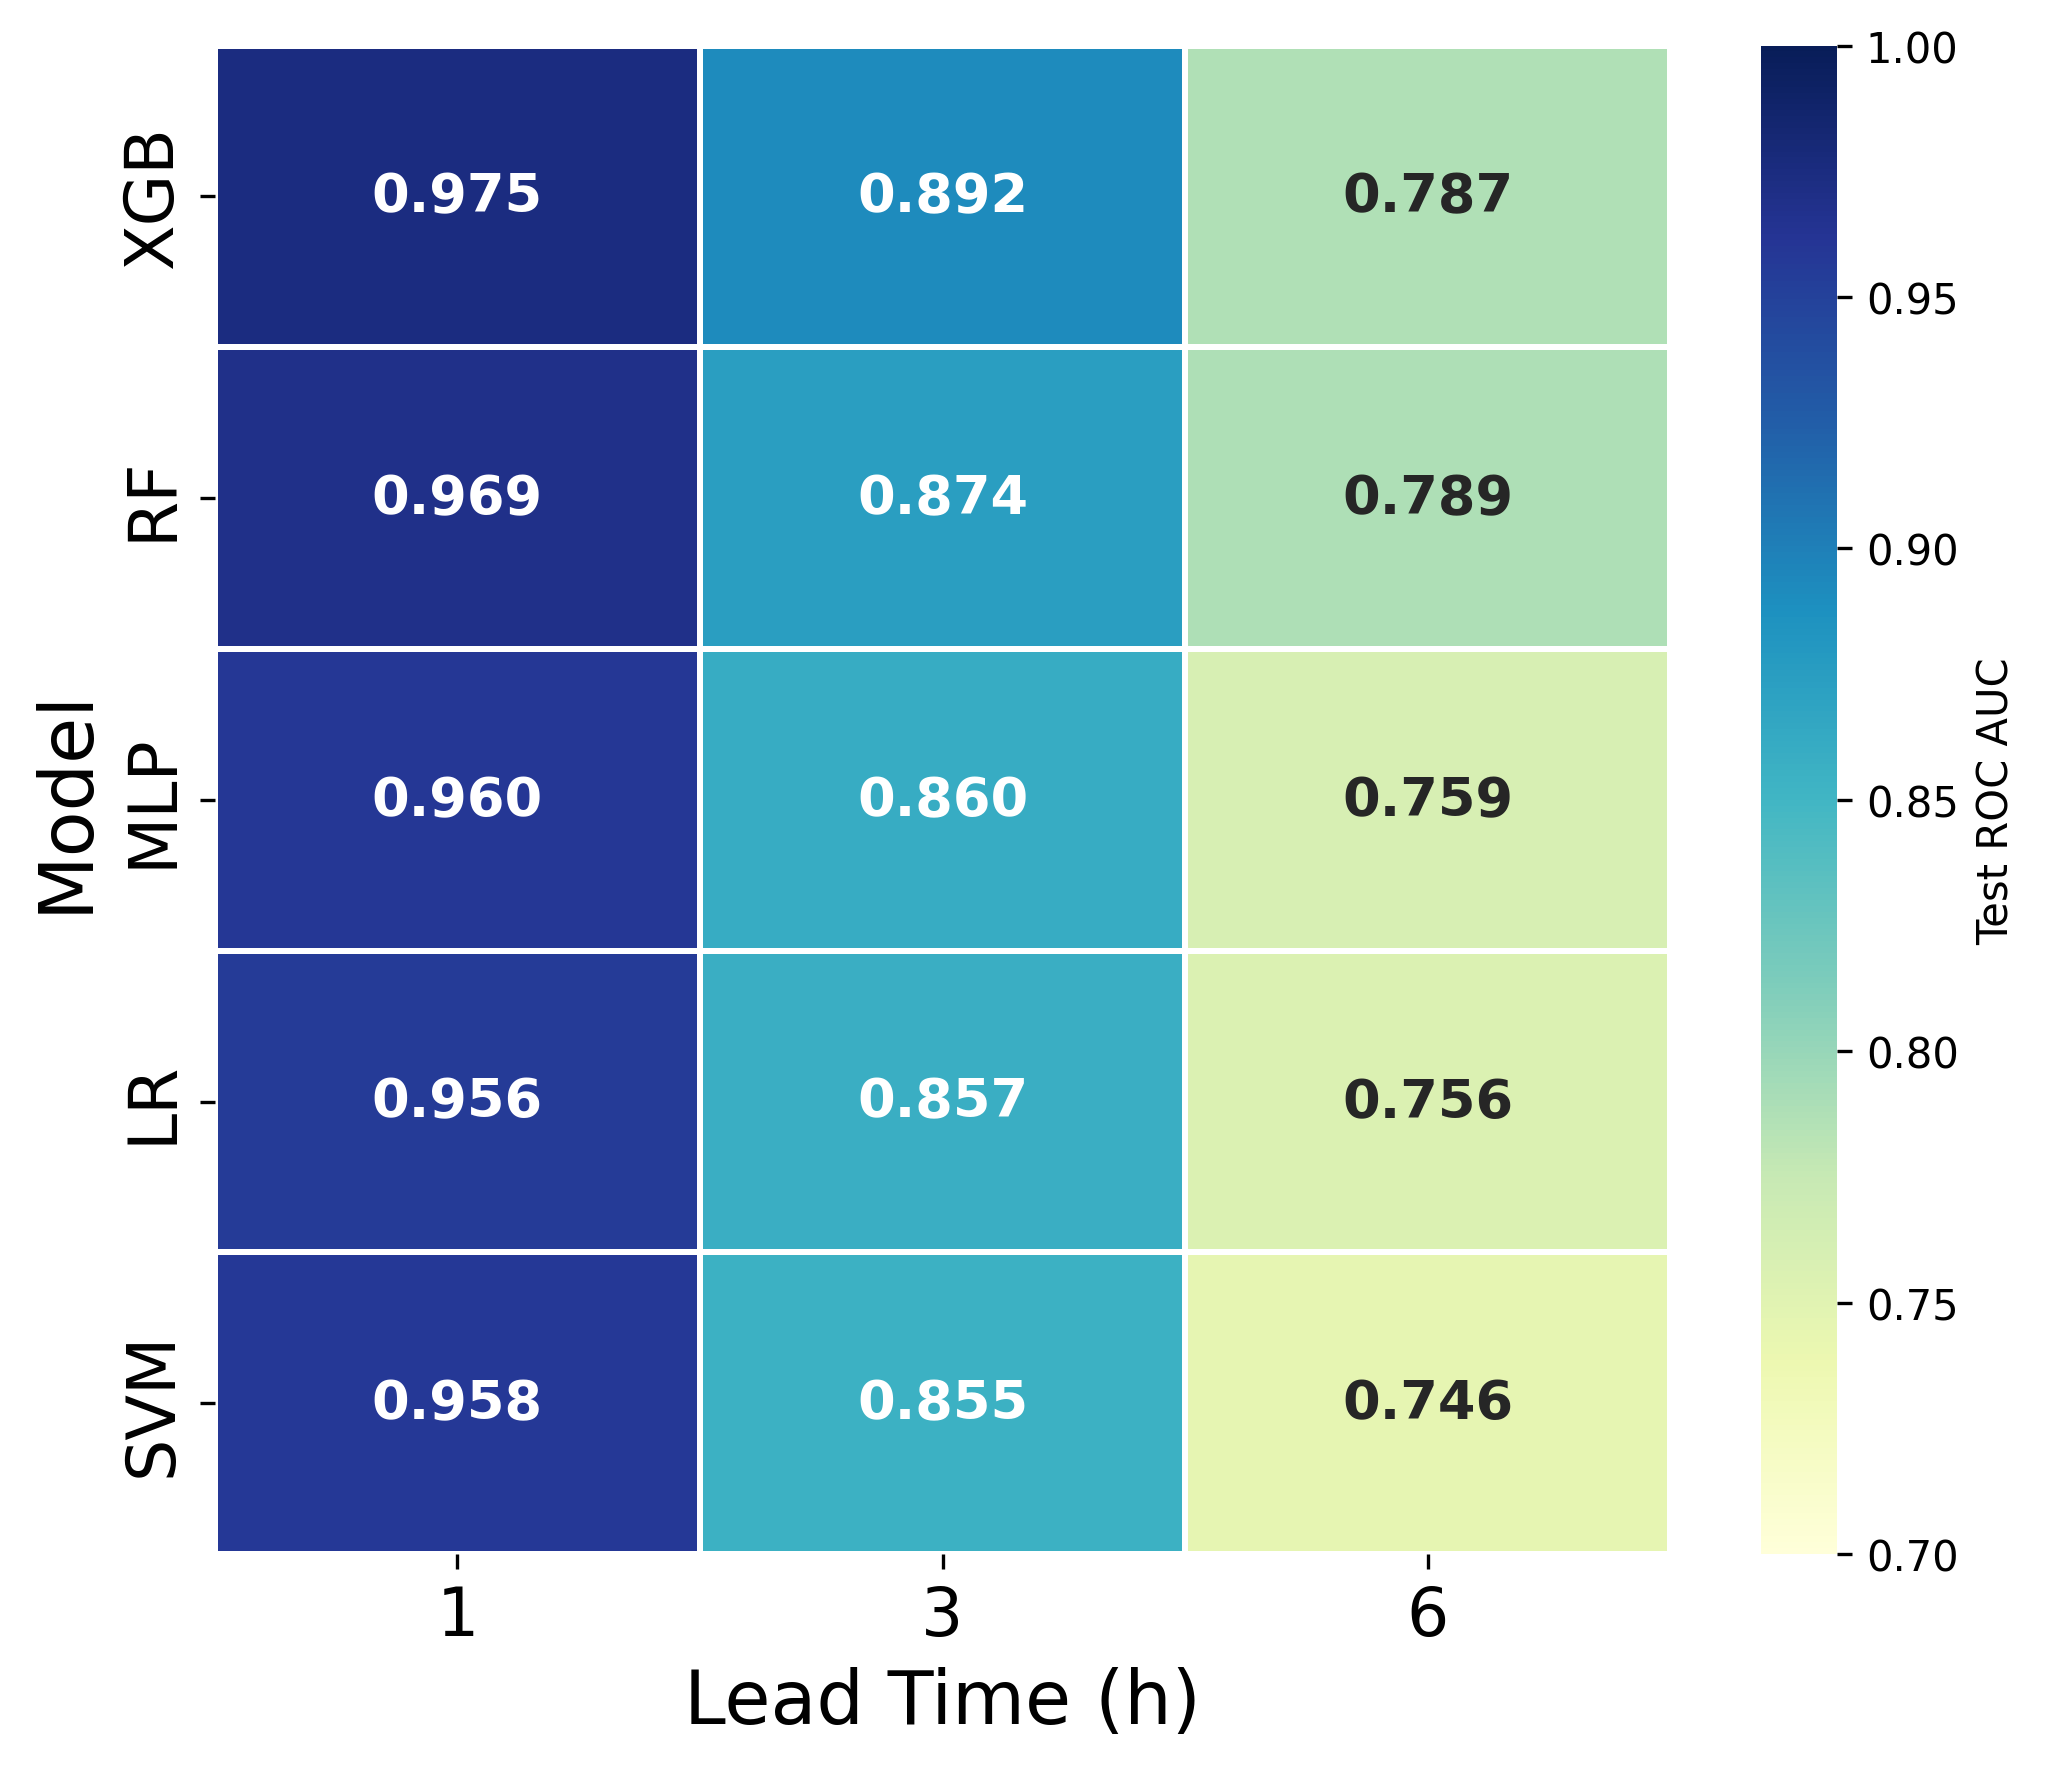

In [ ]:
heatmap_df = results.pivot_table(
    index="model",
    columns="lead_time",
    values="test_auc"
)

model_order = [
    "XGB",
    "RF",
    "MLP",
    "LR",
    "SVM"
]

heatmap_df = heatmap_df.reindex(model_order)


plt.figure(figsize=(7, 6), dpi=300)


sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    annot_kws={
        "fontsize": 13,
        "fontweight": "bold"
    },
    vmin=0.70,
    vmax=1.00,
    cbar_kws={
        "label": "Test ROC AUC"
    }
)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.xlabel("Lead Time (h)", fontsize=18)
plt.ylabel("Model", fontsize=18)

plt.tight_layout()

plt.show()

In [8]:
heatmap_df

,1h,3h,6h
model,,,
XGB,0.974685,0.891744,0.786966
RF,0.968629,0.873776,0.788869
MLP,0.960046,0.859663,0.758832
LR,0.955923,0.857421,0.755624
SVM,0.957932,0.855442,0.745549
